In [37]:
%pip install --upgrade pip -q
%pip install scipy -q
%pip install pycountry -q
%pip install country-converter -q
%pip install seaborn -q
%pip install numpy -q
%pip install plotly -q
%pip install python-dotenv -q
%pip install neo4j -q
%pip install pyarrow fastparquet -q
%pip install nbformat -q
#%pip install py2neo networkx -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you 

In [ ]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

{'status': 'ok', 'restart': True}

: 

# Preamble

In [1]:
from datetime import datetime
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy import stats
import plotly.express as px
from dotenv import load_dotenv
import seaborn as sns
import pycountry
import country_converter

from neo4j import GraphDatabase

# visualization of the graph here
#import networkx as nx
#from py2neo import Graph
#from IPython.display import HTML, display
#import json

In [2]:
start_date = datetime(2025, 7, 11)

# Loading aggregated data

Run the download_data.sh script first.  

## RQ1 DMARC adoption on cctld level

In [3]:
input_path = f"../data/oi-warehouse/testing/source=tranco/cctld_dmarc/year={start_date.year}/month={start_date.month:02d}/day={start_date.day:02d}"

cctld_dmarc_pdf = pd.read_parquet(input_path)
print(cctld_dmarc_pdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164388 entries, 0 to 164387
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   tld          164388 non-null  object
 1   query_name   164388 non-null  object
 2   apex_domain  164080 non-null  object
 3   p            163387 non-null  object
 4   sp           35749 non-null   object
 5   aspf         34010 non-null   object
 6   adkim        28467 non-null   object
 7   rua_domains  164388 non-null  object
 8   ruf_domains  164388 non-null  object
dtypes: object(9)
memory usage: 11.3+ MB
None


In [4]:
def is_policy_strict(p, sp):
    if p in ['none', None, 'invalid']:
        return False
    if sp in ['none', 'invalid']:
        return False
    return True


cctld_dmarc_pdf['is_policy_strict'] = cctld_dmarc_pdf[["p", "sp"]].apply(lambda x: is_policy_strict(x.iloc[0], x.iloc[1]), axis=1)
display(cctld_dmarc_pdf.head(5))

,tld,query_name,apex_domain,p,sp,aspf,adkim,rua_domains,ruf_domains,is_policy_strict
0,kr,_dmarc.0db.co.kr.,0db.co.kr,none,None,None,None,[],[],False
1,fm,_dmarc.1.fm.,1.fm,quarantine,None,None,None,[],[],True
2,at,_dmarc.1000things.at.,1000things.at,quarantine,None,None,None,[1000things.at],[1000things.at],True
3,by,_dmarc.10gkb.by.,10gkb.by,reject,None,s,None,[],[],True
4,nl,_dmarc.112brabant.nl.,112brabant.nl,none,None,None,None,[],[],False


In [37]:
def get_country_from_tld(tld):
    if tld:
        x = tld
        if 'gov' == tld:
            return 'USA'
        if 'gov' in tld:
            x = tld.split('.')[-1]
        if x == 'scot':
            x = 'uk'
        if pycountry.countries.get(alpha_2=x):
            return pycountry.countries.get(alpha_2=x).alpha_3
        return country_converter.convert(x)  # cover 'uk' domains for example
    return None


def get_aggr_policy_count_per_country(cctld_dmarc_pdf):
    # Count policies per country (TLD)
    policy_counts_pdf = cctld_dmarc_pdf.groupby('tld')['is_policy_strict'].agg([
        ('strict_policies', 'sum'),  # Count of True values
        ('relaxed_policies', lambda x: (~x).sum())  # Count of False values
    ]).reset_index()

    # Rename 'tld' to 'country' for clarity
    #policy_counts_pdf.rename(columns={'tld': 'country'}, inplace=True)

    # 'country' (3-letter ISO codes), 'strict_policies', 'relaxed_policies'
    policy_counts_pdf["country"] = policy_counts_pdf["tld"].apply(lambda x: get_country_from_tld(x))

    print("wrongly assigned countries:")  # e.g. country_converter.convert('gov') == 'not found'
    print(len(policy_counts_pdf[(policy_counts_pdf["country"].isna()) | (policy_counts_pdf["country"] == "not found") | (policy_counts_pdf["country"] == "")]))

    # Aggregate by country to handle cases like USA having both 'gov' and 'us' TLDs
    policy_counts_pdf = policy_counts_pdf.groupby('country').agg({
        'strict_policies': 'sum',
        'relaxed_policies': 'sum'
    }).reset_index()

    # Calculate ratio (handling division by zero)
    policy_counts_pdf['difference'] = policy_counts_pdf['strict_policies'] - policy_counts_pdf['relaxed_policies']
    # if relaxed policy is 0, then there will be a div by zero error... just assign 1 to those. and it won't affect the ratio.
    policy_counts_pdf.loc[policy_counts_pdf['relaxed_policies'] == 0, 'relaxed_policies'] = 1
    policy_counts_pdf['ratio'] = policy_counts_pdf['strict_policies'] / (policy_counts_pdf['relaxed_policies'])
    policy_counts_pdf['total_policies'] = policy_counts_pdf['strict_policies'] + policy_counts_pdf['relaxed_policies']

    return policy_counts_pdf

policy_counts_pdf = get_aggr_policy_count_per_country(cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


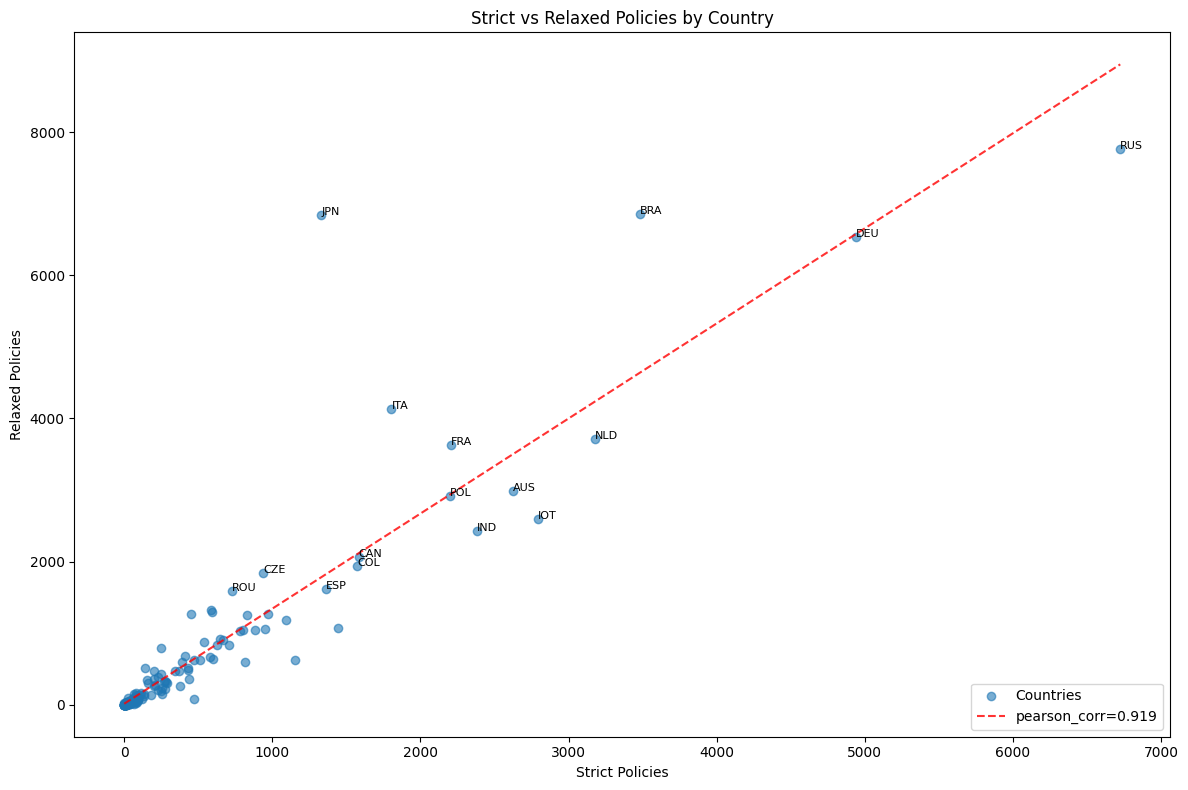

In [50]:
def strict_relaxed_policy_correlation(policy_counts_pdf, threshold):

    plt.figure(figsize=(12, 8))
    plt.scatter(policy_counts_pdf['strict_policies'], policy_counts_pdf['relaxed_policies'], alpha=0.6, label='Countries')

    # Calculate Pearson correlation
    pearson_r, p_value = stats.pearsonr(policy_counts_pdf['strict_policies'], 
                                        policy_counts_pdf['relaxed_policies'])

    # Calculate regression line
    z = np.polyfit(policy_counts_pdf['strict_policies'], 
                policy_counts_pdf['relaxed_policies'], 1)
    p = np.poly1d(z)

    # Plot regression line
    x_line = np.linspace(policy_counts_pdf['strict_policies'].min(), 
                        policy_counts_pdf['strict_policies'].max(), 100)
    plt.plot(x_line, p(x_line), "r--", alpha=0.8, 
            label=f'pearson_corr={pearson_r:.3f}')

    # Add labels for interesting points (optional)
    for idx, row in policy_counts_pdf.iterrows():
        if row['strict_policies'] > threshold or row['relaxed_policies'] > threshold:
            plt.annotate(row['country'], (row['strict_policies'], row['relaxed_policies']), fontsize=8)

    # Add legend with Pearson correlation in bottom right
    legend_text = f'Pearson r = {pearson_r:.3f} (p = {p_value:.3f})'
    plt.legend(loc='lower right') #, title=legend_text, title_fontsize=12)

    plt.xlabel('Strict Policies')
    plt.ylabel('Relaxed Policies')
    plt.title('Strict vs Relaxed Policies by Country')
    plt.tight_layout()
    plt.show()

strict_relaxed_policy_correlation(policy_counts_pdf.copy(), threshold=1500)

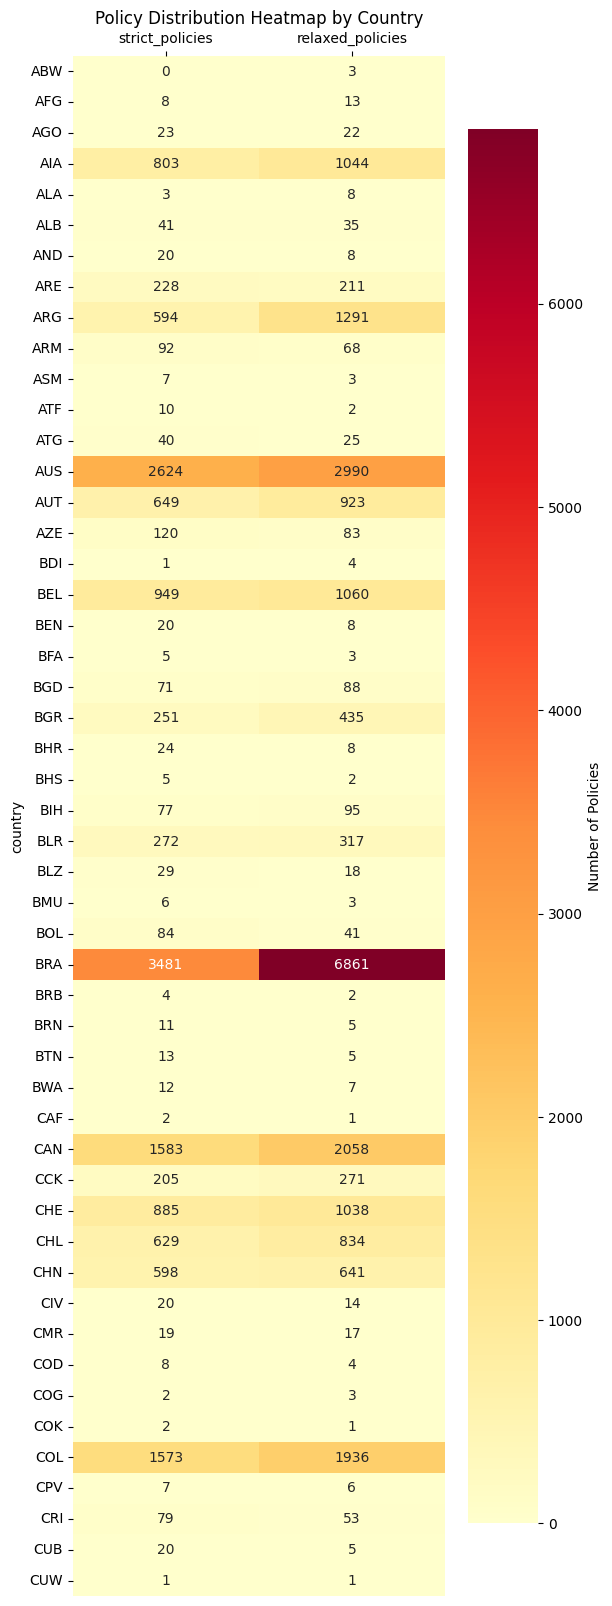

In [56]:
def policy_distribution_heatmap(policy_counts_pdf):
    # Reshape data for heatmap
    heatmap_data = policy_counts_pdf.set_index('country')[['strict_policies', 'relaxed_policies']]

    # Create heatmap (show top 50 for readability)
    plt.figure(figsize=(6, 20))
    sns.heatmap(heatmap_data.head(50), 
                annot=True, 
                fmt='d', 
                cmap='YlOrRd',
                cbar_kws={'label': 'Number of Policies'})
    
    plt.title('Policy Distribution Heatmap by Country')
    plt.yticks(rotation=0)
    plt.gca().xaxis.tick_top()  # Move x-axis labels to top
    plt.gca().xaxis.set_label_position('top')  # Move x-axis label to top
    plt.show()

policy_distribution_heatmap(policy_counts_pdf.copy())

In [35]:
def world_plot_ratio(copy_policy_counts_pdf):
    # Calculate percentage of strict policies for hover info
    copy_policy_counts_pdf['pct_strict'] = (copy_policy_counts_pdf['strict_policies'] / copy_policy_counts_pdf['total_policies']) * 100

    # Create the choropleth map
    fig = px.choropleth(copy_policy_counts_pdf,
                        locations='country',  # Your 3-letter country codes
                        locationmode='ISO-3',
                        color='ratio',
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'total_policies': ':,',
                            'pct_strict': ':.1f',
                            'ratio': ':.2f'
                        },
                        color_continuous_scale='RdBu_r',  # Red for high ratio (more strict), Blue for low
                        labels={
                            'ratio': 'Strict/Relaxed Ratio',
                            'strict_policies': 'Strict Policies',
                            'relaxed_policies': 'Relaxed Policies',
                            'total_policies': 'Total Policies',
                            'pct_strict': '% Strict'
                        },
                        title='DMARC Policy Strictness Ratio by Country')

    # Update layout for better visualization
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        coloraxis_colorbar=dict(
            title="Strict/Relaxed<br>Ratio",
            tickmode='linear',
            tick0=0,
            dtick=0.5,
            len=0.7,
            thickness=15
        ),
        height=700,
        title={
            'text': 'DMARC Policy Strictness Ratio by Country',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        }
    )

    # Customize hover template
    fig.update_traces(
        hovertemplate='<b>%{hovertext}</b><br>' +
                    'Strict Policies: %{customdata[0]}<br>' +
                    'Relaxed Policies: %{customdata[1]}<br>' +
                    'Total Policies: %{customdata[2]}<br>' +
                    'Percent Strict: %{customdata[3]:.1f}%<br>' +
                    'Ratio: %{customdata[4]:.2f}<extra></extra>'
    )

    fig.show()

def world_plot_differences(copy_policy_counts_pdf):
    # Use the 3-letter ISO codes for the map
    fig2 = px.choropleth(copy_policy_counts_pdf,
                                locations='country',
                                locationmode='ISO-3',
                                color='difference',
                                hover_name='country',
                                hover_data={
                                    'strict_policies': ':,',
                                    'relaxed_policies': ':,',
                                    'difference': ':,'
                                },
                                color_continuous_scale='RdBu_r',
                                color_continuous_midpoint=0,
                                range_color=[copy_policy_counts_pdf['difference'].min(),
                                            copy_policy_counts_pdf['difference'].max()],
                                labels={'difference': 'Policy Difference'},
                                title='DMARC Policy Difference by Country (Red=More Strict, Blue=More Relaxed)')

    fig2.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
    )

    fig2.show()

def world_plot_ratio_categories(copy_policy_counts_pdf):
    # Optional: Create intervals for categorical coloring
    highest_ratio = copy_policy_counts_pdf['ratio'].max()
    l = 'strict/relaxed policy ratio categories'

    intervals = [0.0, 0.5, 1.0, 2.0, highest_ratio]

    # Define the category labels in the order you want them
    category_labels = [
        f'Mostly Relaxed ({intervals[0]}:{intervals[1]}]',
        f'Balanced-Relaxed ({intervals[1]}:{intervals[2]}]',
        f'Balanced-Strict ({intervals[2]}:{intervals[3]}]',
        f'Mostly Strict ({intervals[3]}:{intervals[4]}]'
    ]

    copy_policy_counts_pdf[l] = pd.cut(copy_policy_counts_pdf['ratio'],
                                            bins=intervals,
                                            labels=category_labels)

    fig3 = px.choropleth(copy_policy_counts_pdf,
                        locations='country',
                        locationmode='ISO-3',
                        color=l,
                        hover_name='country',
                        hover_data={
                            'strict_policies': ':,',
                            'relaxed_policies': ':,',
                            'ratio': ':.2f'
                        },
                        color_discrete_map={
                            category_labels[0]: '#2166ac',
                            category_labels[1]: '#92c5de', 
                            category_labels[2]: '#f4a582',
                            category_labels[3]: '#b2182b'  # Use the dynamic label
                        },
                        category_orders={l: category_labels},
                        title='DMARC Policy Categories by Country')

    fig3.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='natural earth'
        ),
        height=700,
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=-0.1,
            xanchor='center',
            x=0.5
        )
    )

    fig3.show()


world_plot_ratio_categories(policy_counts_pdf.copy())
#world_plot_ratio(policy_counts_pdf.copy())
#world_plot_differences(policy_counts_pdf.copy())

In [51]:
# Summary statistics
def print_statistics(policy_counts_pdf):
    print("\n=== DMARC Policy Ratio Statistics ===")
    print(f"Countries with more strict than relaxed (ratio > 1): {(policy_counts_pdf['ratio'] > 1).sum()}")
    print(f"Countries with more relaxed than strict (ratio <= 1): {(policy_counts_pdf['ratio'] <= 1).sum()}")
    print(f"\nMean ratio: {policy_counts_pdf['ratio'].mean():.2f}")

    print(f"\nTop 5 strictest countries (by ratio):")
    print(policy_counts_pdf.nlargest(5, 'ratio')[['country', 'ratio', 'strict_policies', 'relaxed_policies']])

    print(f"\nTop 5 most relaxed countries (by ratio):")
    print(policy_counts_pdf.nsmallest(5, 'ratio')[['country', 'ratio', 'strict_policies', 'relaxed_policies']])

print_statistics(policy_counts_pdf)


=== DMARC Policy Ratio Statistics ===
Countries with more strict than relaxed (ratio > 1): 102
Countries with more relaxed than strict (ratio <= 1): 130

Mean ratio: 1.29

Top 5 strictest countries (by ratio):
    country     ratio  strict_policies  relaxed_policies
81      GRL  9.000000               18                 2
71      GBR  6.116883              471                77
77      GLP  6.000000               12                 2
11      ATF  5.000000               10                 2
147     NER  5.000000               10                 2

Top 5 most relaxed countries (by ratio):
    country     ratio  strict_policies  relaxed_policies
0       ABW  0.000000                0                 3
189     SSD  0.000000                0                 2
219     VAT  0.043478                1                23
103     JPN  0.194705             1331              6836
16      BDI  0.250000                1                 4


### government domains

In [9]:
gov_cctld_dmarc_pdf = cctld_dmarc_pdf[cctld_dmarc_pdf['tld'].str.contains('gov')]

In [62]:
cctld_dmarc_pdf[cctld_dmarc_pdf["tld"] == 'ru']

,tld,query_name,apex_domain,p,sp,aspf,adkim,rua_domains,ruf_domains,is_policy_strict
14,ru,_dmarc.adanatgroup.ru.,adanatgroup.ru,reject,None,None,None,[adanatgroup.ru],[],True
16,ru,_dmarc.adminrus.ru.,adminrus.ru,none,reject,r,r,[vipadmin24.ru],[vipadmin24.ru],False
30,ru,_dmarc.allweneed.ru.,allweneed.ru,none,None,None,None,[allweneed.ru],[allweneed.ru],False
40,ru,_dmarc.ano-dea.ru.,ano-dea.ru,none,none,r,None,[],[],False
43,ru,_dmarc.ao-rr.ru.,ao-rr.ru,reject,None,None,None,[ao-rr.ru],[],True
...,...,...,...,...,...,...,...,...,...,...
164330,ru,_dmarc.v-tagile.ru.,v-tagile.ru,none,none,r,None,[],[],False
164336,ru,_dmarc.vdkanal.ru.,vdkanal.ru,none,none,r,None,[],[],False
164350,ru,_dmarc.vpk-news.ru.,vpk-news.ru,none,None,None,None,[],[],False
164351,ru,_dmarc.vsuwt.ru.,vsuwt.ru,quarantine,None,None,None,[vsuwt.ru],[vsuwt.ru],True


In [38]:
gov_policy_counts_pdf = get_aggr_policy_count_per_country(gov_cctld_dmarc_pdf.copy())

wrongly assigned countries:
0


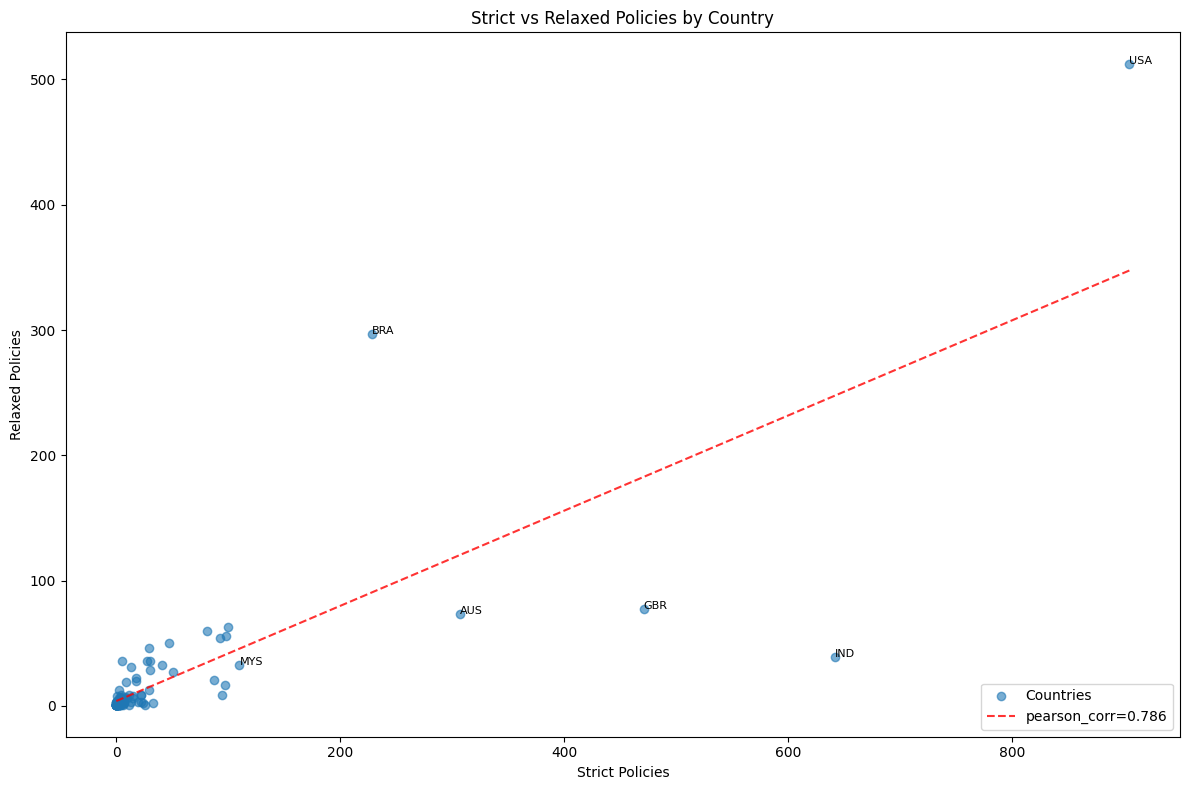

In [52]:
strict_relaxed_policy_correlation(gov_policy_counts_pdf.copy(), threshold=100)

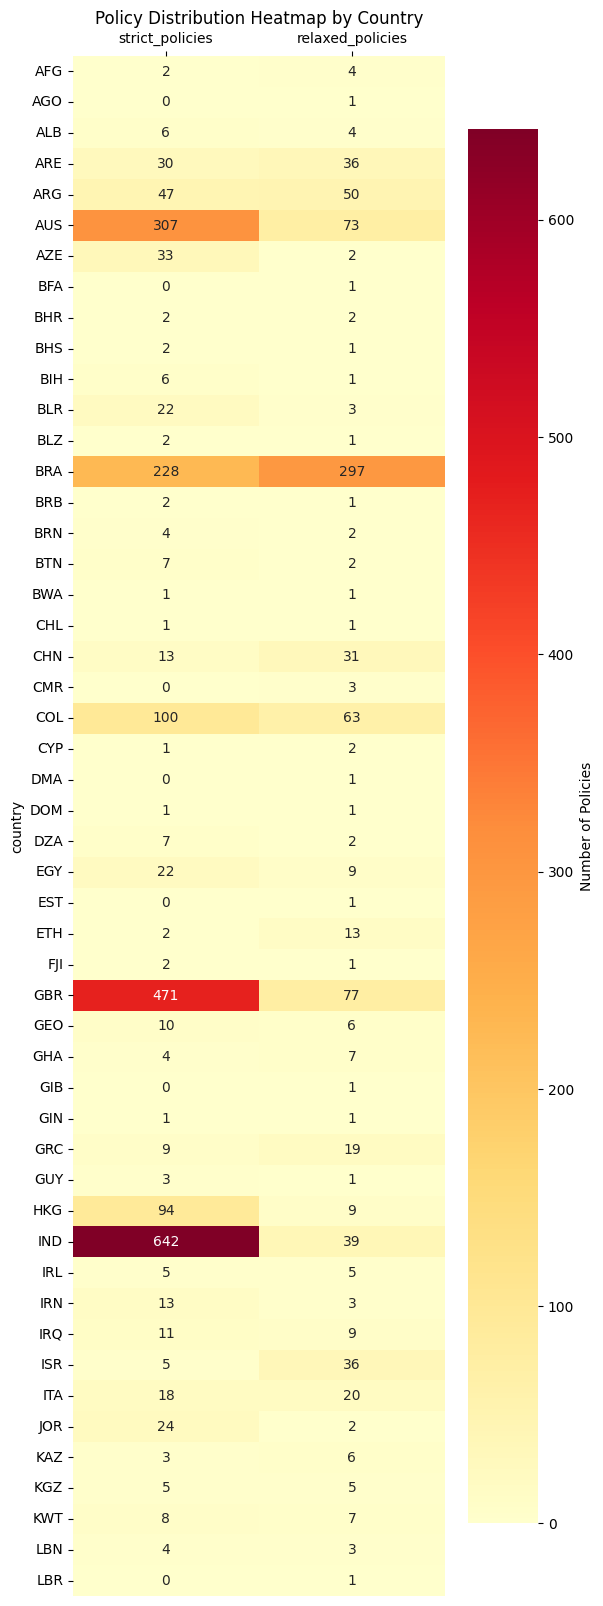

In [57]:
policy_distribution_heatmap(gov_policy_counts_pdf.copy())

In [58]:
world_plot_ratio_categories(gov_policy_counts_pdf.copy())

## RQZ

In [59]:
aggr_rua_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=rua_addresses/").rename(columns={"sum(count)": "count"})
aggr_ruf_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=ruf_addresses/").rename(columns={"sum(count)": "count"})

aggr_rua_pdf["rua_apex_domain"] = aggr_rua_pdf['rua_apex_domain'] = aggr_rua_pdf['rua_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})
aggr_ruf_pdf["ruf_apex_domain"] = aggr_ruf_pdf['ruf_apex_domain'] = aggr_ruf_pdf['ruf_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})

aggr_rua_ruf_pdf = pd.concat([
    aggr_rua_pdf.rename(columns={"rua_apex_domain": "rua_ruf_apex_domain"}), 
    aggr_ruf_pdf.rename(columns={"ruf_apex_domain": "rua_ruf_apex_domain"})
], ignore_index=True).drop(columns=["source", "year", "month", "day"]
).groupby("rua_ruf_apex_domain", as_index=False).agg(count=("count", "sum")
).sort_values("count", ascending=False)
aggr_rua_ruf_pdf["percent"] = aggr_rua_ruf_pdf["count"] / aggr_rua_ruf_pdf["count"].sum() * 100

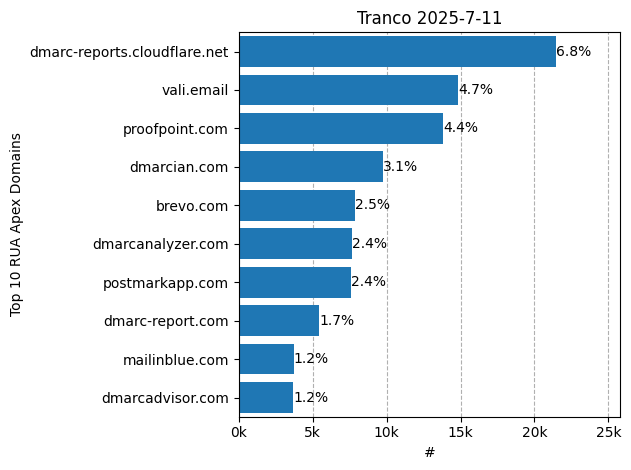

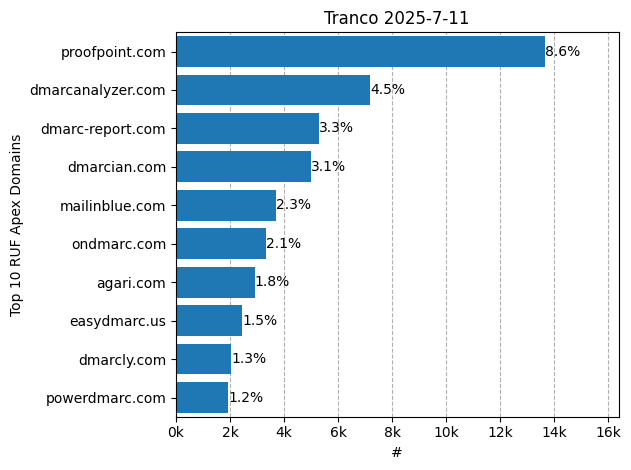

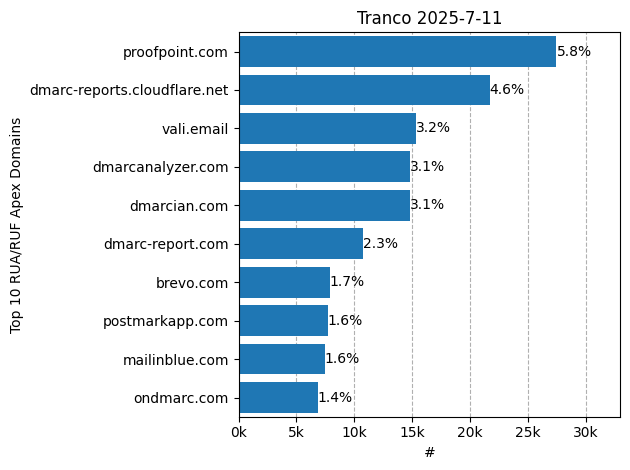

In [60]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel, start_date):
    plt.figure()

    _ = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.title(f"Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.xlim(0, top_n["count"].max() * 1.2)
    thousands = ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
    plt.gca().xaxis.set_major_formatter(thousands)
    plt.gca().set_axisbelow(True)
    plt.gca().xaxis.grid(True, linestyle='--')

    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top

    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()


_plot_dmarc_ruaruf_tag(aggr_rua_pdf.head(10), "rua_apex_domain", "Top 10 RUA Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_ruf_pdf.head(10), "ruf_apex_domain", "Top 10 RUF Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_rua_ruf_pdf.head(10), "rua_ruf_apex_domain", "Top 10 RUA/RUF Apex Domains", start_date)

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  

#### Neo4j connection

In [5]:
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.uri = uri
        self.user = user
        self.password = password
        self.driver = None

    def __enter__(self):
        """Enter the context manager - establish connection"""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the context manager - close connection"""
        if self.driver:
            self.driver.close()

    def test_connection(self):
        with self.driver.session() as session:
            result = session.run("RETURN 'Connection successful' as message")
            print(result.single()["message"])

    def query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]

    def query_to_df(self, query, parameters=None):
        results = self.query(query, parameters)
        return pd.DataFrame(results)

    def write_query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return result.consume().counters

load_dotenv()
NEO4J_PASSWD = os.getenv('NEO4J_PASSWD')
if not NEO4J_PASSWD:
    raise ValueError("NEO4J_PASSWD not found in environment variables")

URI = "bolt://localhost:7687"
AUTH = ("neo4j", NEO4J_PASSWD)

Warning! RUN THIS ONLY ONCE TO SET UP THE DATABASE

In [64]:
with Neo4jConnection(URI, *AUTH) as conn:
    conn.test_connection()
    conn.write_query("CREATE INDEX vertices_id_index IF NOT EXISTS FOR (n:Vertices) ON (n.id)")
    conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row
            CREATE (:Vertices {id: row.id})
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    result = conn.query("MATCH (n:Vertices) RETURN count(n) as total_vertices")
    print(f"Total vertices in database: {result[0]['total_vertices']}")

    result_rua = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///rua_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUA]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUA edges created: {result_rua.relationships_created}")

    result_ruf = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///ruf_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUF]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUF edges created: {result_ruf.relationships_created}")

Connection successful
Total vertices in database: 439947
RUA edges created: 315274
RUF edges created: 158219


In [ ]:
# cleaning up the database
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    conn.query("""
        CALL gds.graph.drop('DMARC')
    """)

    conn.query("""
        MATCH ()-[r]-()
        DELETE r;
    """)

    conn.query("""
        MATCH (n)
        DELETE n;
    """)

    result = conn.query("""
        MATCH (n)
        RETURN count(n) AS node_count
    """)
    print(f"Total nodes in database after cleanup: {result[0]['node_count']}")
    result = conn.query("""
        MATCH ()-[r]-()
        RETURN count(r) AS relationship_count
    """)
    print(f"Total relationships in database after cleanup: {result[0]['relationship_count']}")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 2, column: 9, offset: 9} for query: "\n        CALL gds.graph.drop('DMARC')\n    "


Best visualized at cypher using:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
RETURN n, r, m  
LIMIT 50;  


Visualize individual nodes:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
WHERE n.id = "bibleminute.co"  
RETURN n, r, m  

##### Local visualization -- not good

In [ ]:
def visualize_with_existing_connection(conn, query, limit=50):
    # Get data using your existing connection
    data = conn.query(f"{query} LIMIT {limit}")

    # Create NetworkX graph
    G = nx.DiGraph()  # Directed graph for RUA/RUF relationships

    # Process the data
    for record in data:
        if 'source' in record and 'target' in record:
            G.add_edge(record['source'], record['target'], 
                      rel_type=record.get('relationship', 'CONNECTED'))

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Different colors for different relationship types
    edge_colors = []
    for u, v, d in G.edges(data=True):
        if d.get('rel_type') == 'RUA':
            edge_colors.append('red')
        elif d.get('rel_type') == 'RUF':
            edge_colors.append('blue')
        else:
            edge_colors.append('gray')

    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', 
                          node_size=300, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, 
                          arrows=True, arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    plt.title(f"Graph Visualization ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"Nodes: {len(G.nodes())}")
    print(f"Edges: {len(G.edges())}")

    return G

# horrible visualization; no other better python choice... use cypher which is better
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # Query that returns source, target, relationship
    query = """
        MATCH (n:Vertices)-[r]->(m:Vertices)
        RETURN n.id as source, m.id as target, type(r) as relationship
    """

    graph = visualize_with_existing_connection(conn, query, limit=50)

#### Connected Components algorithm

In [ ]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    current_graphs = conn.query("""
        CALL gds.graph.list()
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
        ORDER BY graphName
    """)

    if current_graphs:
        print("Current graph projections:")
        for graph in current_graphs:
            print(f"  {graph['graphName']}: {graph['nodeCount']} nodes, {graph['relationshipCount']} relationships")
        if False: # delete graph!
            for graph in current_graphs:
                conn.write_query(f"CALL gds.graph.drop({graph['graphName']}) YIELD graphName;")
                print(f"Dropped existing graph projection {graph['graphName']}.")
    else:
        conn.write_query("""
            CALL gds.graph.project(
                'DMARC',
                'Vertices',
                ['RUA', 'RUF']
            )
        """)

#  DMARC: 439947 nodes, 473493 relationships


Current graph projections:
  DMARC: 439947 nodes, 473493 relationships


In [67]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        RETURN  componentId, 
                collect(gds.util.asNode(nodeId).id) AS node_ids,
                size(collect(gds.util.asNode(nodeId).id)) AS component_size
        ORDER BY size(node_ids) DESC
        LIMIT 10;
    """)
    display(result_pdf)

,componentId,node_ids,component_size
0,0,"[kimballmidwest.com, cheval-shop.com, milleniu...",147177
1,1966,"[army-surplus.cz, defendia.cz, brainmarket.sk,...",150
2,1849,"[bmw.hu, alphabet.pl, mini.es, mini.my, mini.c...",109
3,2551,"[ta.no, bygdeposten.no, dt.no, laagendalsposte...",91
4,6212,"[thepoliticalglobe.com, republicanpress.org, t...",89
5,3628,"[housetrip.com, flipkey.com, tripadvisor.co.kr...",83
6,1995,"[actu-femmes-senior.fr, infocronacanera.it, vo...",78
7,4031,"[inwentury.pl, griggio.pl, brd.edu.pl, bestspe...",67
8,1962,"[netdoktor.se, ljusdalsposten.se, skovdenyhete...",64
9,3236,"[blpprofessional.com, bloomberg.com.br, bloomb...",60


In [68]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    clusters_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        WITH componentId, collect(gds.util.asNode(nodeId).id) AS node_ids
        WHERE size(node_ids) > 1  // Only multi-node components

        // For each component, get top n most connected nodes
        UNWIND node_ids AS node_id
        MATCH (target:Vertices {id: node_id})
        OPTIONAL MATCH (source:Vertices)-[r:RUA|RUF]->(target)
        WHERE source.id IN node_ids
        WITH componentId, node_ids, target.id AS vertex_id, count(r) AS incoming_count
        ORDER BY componentId, incoming_count DESC

        // Get top 5 nodes per component
        //WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count})[0..5] AS top_nodes
        WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count}) AS top_nodes

        RETURN componentId,
            size(node_ids) AS component_size,
            top_nodes
        ORDER BY component_size DESC
        //LIMIT 10;
    """)
    display(clusters_pdf)

,componentId,component_size,top_nodes
0,0,147177,"[{'incoming': 27462, 'vertex': 'proofpoint.com..."
1,1966,150,"[{'incoming': 300, 'vertex': 'leadhub.co'}, {'..."
2,1849,109,"[{'incoming': 216, 'vertex': 'bmwgroup.com'}, ..."
3,2551,91,"[{'incoming': 91, 'vertex': 'amedia.no'}, {'in..."
4,6212,89,"[{'incoming': 88, 'vertex': 'esps5.com'}, {'in..."
...,...,...,...
17405,418485,2,"[{'incoming': 1, 'vertex': 'activesphere.eu'},..."
17406,420829,2,"[{'incoming': 2, 'vertex': 'hightechcampus.com..."
17407,432229,2,"[{'incoming': 1, 'vertex': 'dracnet.com'}, {'i..."
17408,435314,2,"[{'incoming': 1, 'vertex': 'DULICHVIET.COM.VN'..."


In [ ]:
# row 6 is tripadvisor
display(clusters_pdf["top_nodes"].iloc[5])

[{'incoming': 143, 'vertex': 'tripadvisor.com'},
 {'incoming': 0, 'vertex': 'housetrip.com'},
 {'incoming': 0, 'vertex': 'flipkey.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.co.kr'},
 {'incoming': 0, 'vertex': 'tripadvisor.ca'},
 {'incoming': 0, 'vertex': 'cruisecritic.com.au'},
 {'incoming': 0, 'vertex': 'tripadvisor.cn'},
 {'incoming': 0, 'vertex': 'viatorsystems.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.cl'},
 {'incoming': 0, 'vertex': 'cruisecritic.co.uk'},
 {'incoming': 0, 'vertex': 'thefork.it'},
 {'incoming': 0, 'vertex': 'tripadvisor.jp'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.eg'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.vn'},
 {'incoming': 0, 'vertex': 'tripadvisor.at'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.tr'},
 {'incoming': 0, 'vertex': 'thefork.nl'},
 {'incoming': 0, 'vertex': 'tripadvisor.de'},
 {'incoming': 0, 'vertex': 'tripadvisorsupport.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.sg'},
 {'incoming': 0, 'vertex': 'tripadvisor.sk'},
 {'i

In [82]:
display(clusters_pdf["top_nodes"].iloc[2])

[{'incoming': 216, 'vertex': 'bmwgroup.com'},
 {'incoming': 0, 'vertex': 'bmw.hu'},
 {'incoming': 0, 'vertex': 'alphabet.pl'},
 {'incoming': 0, 'vertex': 'mini.es'},
 {'incoming': 0, 'vertex': 'mini.my'},
 {'incoming': 0, 'vertex': 'mini.co.kr'},
 {'incoming': 0, 'vertex': 'bmwlat.com'},
 {'incoming': 0, 'vertex': 'mini.dk'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.fr'},
 {'incoming': 0, 'vertex': 'bmw.be'},
 {'incoming': 0, 'vertex': 'mini.de'},
 {'incoming': 0, 'vertex': 'bmw.lu'},
 {'incoming': 0, 'vertex': 'bmw-welt.com'},
 {'incoming': 0, 'vertex': 'bmwgroupfs.com'},
 {'incoming': 0, 'vertex': 'bmw.no'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.es'},
 {'incoming': 0, 'vertex': 'bmw.in'},
 {'incoming': 0, 'vertex': 'mini.no'},
 {'incoming': 0, 'vertex': 'bmw.ca'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.de'},
 {'incoming': 0, 'vertex': 'bmw.ch'},
 {'incoming': 0, 'vertex': 'mini.com'},
 {'incoming': 0, 'vertex': 'mini.in'},
 {'incoming': 0, 'vertex': 'bmwgroupdesignworks.com'},
 

Visualization of specific components

// First, get the node IDs for component 2  
CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})  
YIELD nodeId, componentId  
WHERE componentId = 2  
WITH collect(gds.util.asNode(nodeId).id) AS component_nodes  

// Then visualize those nodes and their relationships  
MATCH (n:Vertices)  
WHERE n.id IN component_nodes  
MATCH (n)-[r:RUA|RUF]-(m:Vertices)  
WHERE m.id IN component_nodes  
RETURN n, r, m;  

What are the small clusters?  
Business relationships: subsidiaries sending dmarc report to their holding's mailbox.

If you own multiple domains, it makes sense that all rua and ruf reports are sent to the IT security mailbox, either the holding company, the regional domain or to a 3rd party processor. For instance, regional tripadvisor such as tripadvisor.be send reports to its main region tripadvisor.com. Also, housetrip.com seems a subsidiary of tripadvisor, which also send dmarc reports to tripadvisor.com. The holding company doesn't use any specialized mail security company, and hence, handles the reports in-house.

Although in this example the companies are under the group, they may be in different countries and hence, different data jurisdictions apply.

The "holding", where the reports are sent, can turn into a target because it concentrates information

Can we distinguish subsidiaries and holdings automatically? maybe only using a web crawler...

Are the small clusters sending the report to the same data protection law?

##### Strongly Connected Components

"finds sets of connected nodes in a directed graph where each node is reachable in both directions from any other node in the same set"

In [15]:
with Neo4jConnection(URI, *AUTH) as conn:
    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        WITH componentId, count(nodeId) AS component_size
        RETURN component_size AS ComponentSize, count(*) AS NumberOfComponentsWithThisSize
        ORDER BY ComponentSize DESC
    """)
    display(scc_pdf)

    scc_pdf = conn.query_to_df("""
        CALL gds.scc.stream("DMARC", {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        RETURN componentId, collect(gds.util.asNode(nodeId).id) AS domains
        ORDER BY size(domains) DESC
        LIMIT 20
    """)
    display(scc_pdf)

,ComponentSize,NumberOfComponentsWithThisSize
0,2,17
1,1,439913


,componentId,domains
0,129612,"[birtema.com, temadam.com]"
1,30221,"[ciwf.org, ciwf.org.uk]"
2,62656,"[lukfook.com, jw28.com]"
3,106764,"[metalmarket.eu, metalmarket.eu]"
4,253374,"[peoplefluent.com, peopleclick.com]"
5,412070,"[bit.ly, bitly.net]"
6,24883,"[nuc.co.kr, kuvings.com]"
7,59742,"[kbtg.tech, kasikornbank.com]"
8,101337,"[netservicesgroup.net, netservicesgroup.com]"
9,352522,"[jetmailx.com.br, tavola.com.br]"


Only 17 cases have a 2 domain components that are strongly connected, ie, can reach each other (point to each other). All the other domains are not strongly connected. But we can find communities in them by looking at (weakly) connected components.

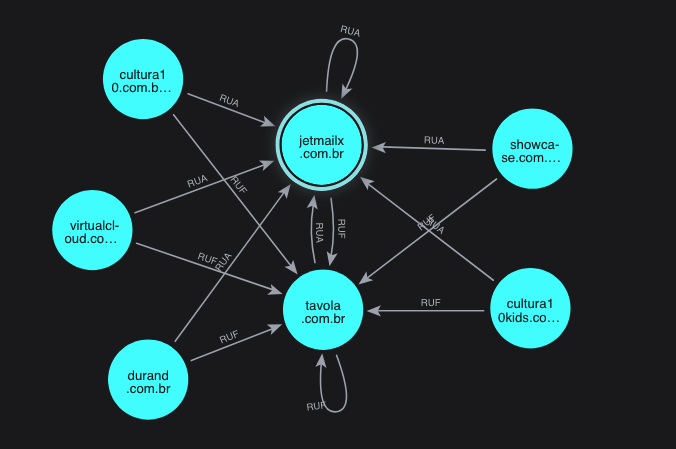

#### Degree Centrality algorithm

"The degree centrality measures the number of incoming or outgoing (or both) relationships from a node, which can be defined by the orientation of a relationship projection. If a projection contains directed relationships, only outgoing relationships of a node are counted (the out-degree)." -- https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/  


In [74]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # this is calculating the outdegree centrality, ie the top 10 domains that send rua/ruf reports to most distinct domains
    print("Calculating degree centrality using out-degree...")
    outdegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_outgoing_links
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 10;
    """)
    display(outdegree_pdf)

    print("Calculating degree centrality using in-degree...")
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_incoming_links
        ORDER BY nr_incoming_links DESC, domains DESC
        LIMIT 10;
    """)
    display(indegree_pdf)

Calculating degree centrality using out-degree...


,domains,nr_outgoing_links
0,bibleminute.co,9.0
1,baymack.com,9.0
2,wespire.com,8.0
3,prodpad.com,8.0
4,paypams.com,8.0
5,mailgun.com,8.0
6,legalvision.com.au,8.0
7,ecareer.ne.jp,8.0
8,corendonairlines.com,8.0
9,stocktradersdaily.com,7.0


Calculating degree centrality using in-degree...


,domains,nr_incoming_links
0,proofpoint.com,27462.0
1,dmarc-reports.cloudflare.net,21679.0
2,vali.email,15332.0
3,dmarcanalyzer.com,14835.0
4,dmarcian.com,14743.0
5,dmarc-report.com,10707.0
6,brevo.com,7886.0
7,postmarkapp.com,7685.0
8,mailinblue.com,7436.0
9,ondmarc.com,6833.0


In [80]:
def add_external_domains_to_pdf(row, src_column, dst_column):
    """Add a column to the DataFrame indicating if the outgoing links are to external domains."""
    src_domain = row[src_column]
    dst_domains = set(row[dst_column])
    row['external_domains'] = []
    for dst_domain in dst_domains:
        # Check if the destination domain is external
        if not dst_domain.endswith(src_domain):
            row['external_domains'] = row.get('external_domains', []) + [dst_domain]

    row['nr_external_domains'] = len(row['external_domains'])
    return row


with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    domains_outdegree_pdf = conn.query_to_df("""
        MATCH (n:Vertices)
        OPTIONAL MATCH (n)-[:RUA|RUF]->(connected)
        WITH n, collect(connected.id) AS outgoing_link_ids, count(connected) AS nr_outgoing_links
        RETURN n.id AS domains, nr_outgoing_links, outgoing_link_ids
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 200
    """)
    # display(domains_outdegree_pdf)

domains_outdegree_pdf = domains_outdegree_pdf.apply(add_external_domains_to_pdf, axis=1, args=('domains', 'outgoing_link_ids'))
display(domains_outdegree_pdf)

,domains,nr_outgoing_links,outgoing_link_ids,external_domains,nr_external_domains
0,bibleminute.co,9,"[250ok.net, radiantdigital.com, dmarcian.com, ...","[dmarcian.com, 250ok.net, radiantdigital.com, ...",4
1,baymack.com,9,"[dmarcian.com, ondmarc.com, mailgun.org, easyd...","[dmarcian.com, easydmarc.asia, dmarc-reports.c...",6
2,wespire.com,8,"[dmarcinput.com, easydmarc.us, uriports.com, g...","[glockapps.com, easydmarc.us, dmarcinput.com, ...",4
3,prodpad.com,8,"[mailgun.org, ondmarc.com, prodpad.com, report...","[mailgun.org, ondmarc.com, report-uri.com]",3
4,paypams.com,8,"[dmarc-report.com, ondmarc.com, dmarcian.com, ...","[dmarcian.com, dmarc-reports.cloudflare.net, p...",5
...,...,...,...,...,...
195,infraspeak.com,6,"[infraspeak.com, easydmarc.eu, dmarcian.com, d...","[dmarcian.com, easydmarc.eu]",2
196,infinx.com,6,"[dmarcinput.com, infinx.com, infinx.com, trend...","[dmarcinput.com, trendmicro.com, dmarc-report....",3
197,infinum.com,6,"[mailhardener.com, uriports.com, infinum.com, ...","[mailhardener.com, uriports.com]",2
198,ify.ch,6,"[dmarcly.com, easydmarc.us, ify.ch, easydmarc....","[easydmarc.us, dmarcly.com]",2


In [79]:
print(
    domains_outdegree_pdf['domains'].iloc[0], domains_outdegree_pdf['external_domains'].iloc[0],
    '\n',
    domains_outdegree_pdf['domains'].iloc[1], domains_outdegree_pdf['external_domains'].iloc[1],
    '\n',
    domains_outdegree_pdf['domains'].iloc[2], domains_outdegree_pdf['external_domains'].iloc[2],
    '\n',
    domains_outdegree_pdf['domains'].iloc[99], domains_outdegree_pdf['external_domains'].iloc[99]
)

bibleminute.co ['dmarcian.com', '250ok.net', 'radiantdigital.com', 'dmarc-report.com'] 
 baymack.com ['dmarcian.com', 'easydmarc.asia', 'dmarc-reports.cloudflare.net', 'mailgun.org', 'ondmarc.com', 'dmarc-report.com'] 
 wespire.com ['glockapps.com', 'easydmarc.us', 'dmarcinput.com', 'uriports.com'] 
 ripc.gov.sa ['dmarc-report.com', 'dmarc.gov.sa']


In [85]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    all_domains_outdegree_pdf = conn.query_to_df("""
        MATCH (n:Vertices)
        OPTIONAL MATCH (n)-[:RUA|RUF]->(connected)
        WITH n, collect(connected.id) AS outgoing_link_ids, count(connected) AS nr_outgoing_links
        RETURN n.id AS domains, nr_outgoing_links, outgoing_link_ids
        ORDER BY nr_outgoing_links DESC, domains DESC
    """)

all_domains_outdegree_pdf = all_domains_outdegree_pdf.apply(add_external_domains_to_pdf, axis=1, args=('domains', 'outgoing_link_ids'))
# percent that have 2 or more external domains
print(f"Percent of domains with 2 or more external domains: {
    all_domains_outdegree_pdf[all_domains_outdegree_pdf['nr_external_domains'] >= 2].shape[0] / all_domains_outdegree_pdf.shape[0] * 100:.1f}%")

Percent of domains with 2 or more external domains: 4.1%


In [94]:
total = all_domains_outdegree_pdf.shape[0]

# put this into a pandas df
summary_df = pd.DataFrame({
    "2 or more external domains": [
        all_domains_outdegree_pdf[all_domains_outdegree_pdf['nr_external_domains'] >= 2].shape[0] / total * 100
    ],
    "1 external domain": [
        all_domains_outdegree_pdf[all_domains_outdegree_pdf['nr_external_domains'] == 1].shape[0] / total * 100
    ],
    "No external domains": [
        all_domains_outdegree_pdf[all_domains_outdegree_pdf['nr_external_domains'] == 0].shape[0] / total * 100
    ],
    "All": [total],
})
# transpose column and rows
summary_df = summary_df.T
summary_df.columns = ['Percent']
summary_df.index.name = 'Category'
summary_df.reset_index(inplace=True)
display(summary_df)

,Category,Percent
0,2 or more external domains,4.119814
1,1 external domain,35.477910
2,No external domains,60.402276
3,All,439947.000000


Why one domain would send the report to multiple mailboxes?  
To send copies of reports to different parties. For example, you can send to a mailbox of your own domain, to a mailbox of an external domain, e.g., the holder company (in case the source domain is a subsidiary company), and send to a company specialized in processing DMARC reports such as DMARCian. One example is bibleminute.co, which is a subsidiary of radiantdigital.com, which sends report to its "holding" and to different email specialized companies.

Sending to multiple specialized companies seems more a configuration mistake.
One can think of distributing the reports to avoid single point of failures (should the primary DMARC processing company mailbox reject to receive the report due to size). But adding more companies to process reports increase costs, add overhead to the source domain that requested outsourcing of processing reports because it will have to manage multiple advises from different dmarc report processing companies Or worse, request to send (in rua/ruf tags) inappropriate reports may spam the mailboxes of those receiving dmarc reports~\cite{dmarc_rfc}.

how many of the out-links are to external domains?

how many of the out-links are to other countries?

#### Self-reporting (no external domains)

In [ ]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:RUA|RUF]->(n)
        RETURN n.id AS self_reporting_domain //,
            //type(r) AS report_type,
            //count(r) AS self_report_count
        //ORDER BY self_report_count DESC;
    """)

    print(len(result_pdf["self_reporting_domain"].unique()))

129574


## RQ2